Question 7.1 : Linear algebra exercises

In [6]:
import numpy as np
from numpy import linalg as la

np.set_printoptions(suppress=True)


A = np.array([1,2,3,0,-4,1,0,3,-1]).reshape(3,3)
print(A)

detA = la.det(A)
print(detA)

b = np.array([2,2,1]).reshape(3,1)

x,y,z = np.dot(la.inv(A),b)

print(f"x = {int(x[0])},y = {int(y[0])},z = {int(z[0])}")

print("A is orthogonal if its transpose is equal to its inverse:")
if (A.T == la.inv(A)).all():
    print("A is orthogonal:)")
else: 
    print("A is not orthogonal:(")
    
Lambda, v = la.eig(A)
print("The eigen values of A are:", Lambda)

[[ 1  2  3]
 [ 0 -4  1]
 [ 0  3 -1]]
1.0
x = 38,y = -3,z = -10
A is orthogonal if its transpose is equal to its inverse:
A is not orthogonal:(
The eigen values of A are: [ 1.         -4.79128785 -0.20871215]


Question 7.3 : Applying a rotation matrix

In [30]:
import numpy as np
from numpy import linalg as la

np.set_printoptions(suppress=True)

z1 = 180-123
y = 90-27.4
z2 = 192.25

Ez1 = np.array([np.cos(np.deg2rad(z1)),np.sin(np.deg2rad(z1)),0,-1*np.sin(np.deg2rad(z1)),np.cos(np.deg2rad(z1)),0,0,0,1]).reshape(3,3)
Ey = np.array([np.cos(np.deg2rad(y)),0,-1*np.sin(np.deg2rad(y)),0,1,0,np.sin(np.deg2rad(y)),0,np.cos(np.deg2rad(y))]).reshape(3,3)
Ez2= np.array([np.cos(np.deg2rad(z2)),np.sin(np.deg2rad(z2)),0,-1*np.sin(np.deg2rad(z2)),np.cos(np.deg2rad(z2)),0,0,0,1]).reshape(3,3)
E = Ez1@Ey@Ez2

print(E)

if np.allclose(E.T,la.inv(E)) and abs(la.det(E)-1)<= 10**-10: # due to Python's limited memory
    print("E is a rotation matrix")
else:
    print("E is not a rotation matrix")
    
print()

Lambda, eigenv = la.eig(E)
print(f"The eigenvalues of E: {Lambda}") # the last eigen value is indeed 1

delta = 27.4
alpha = 192.25

v = [np.cos(np.deg2rad(delta))*np.cos(np.deg2rad(alpha)),np.cos(np.deg2rad(delta))*np.sin(np.deg2rad(alpha)),np.sin(np.deg2rad(delta))]
print(f"The vector v obtained from Eq. 7.16: {np.array(v)}")
L = la.norm(np.array(v))
print(f"The length of v={L}")

v2 = E@v
print(f"The new vector v2 = {v2}")

[[-0.06698874 -0.87275577 -0.48353891]
 [ 0.49272847 -0.45034696  0.74458463]
 [-0.86760081 -0.1883746   0.46019978]]
E is a rotation matrix

The eigenvalues of E: [-0.52856796+0.84889099j -0.52856796-0.84889099j  1.        +0.j        ]
The vector v obtained from Eq. 7.16: [-0.86760081 -0.1883746   0.46019978]
The length of v=1.0
The new vector v2 = [0. 0. 1.]


Question 7.5 : Interpolating polynomial

[[ 218.582332  ]
 [-551.00314615]
 [ 565.81223725]
 [-313.63355584]
 [ 104.54407428]
 [ -21.93313595]
 [   2.91867715]
 [  -0.23905976]
 [   0.01099256]
 [  -0.00021712]]


/tmp/ipykernel_2732868/3821206475.py:29: UserWarning: FigureCanvasAgg is non-interactive, and thus cannot be shown
  fig.show()


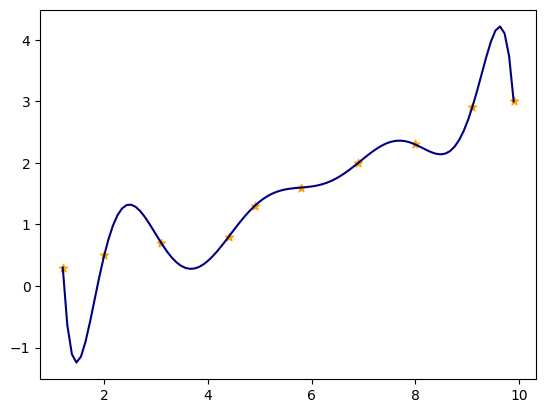

In [39]:
import numpy as np
import matplotlib.pyplot as plt

x = np.array([1.2, 2.0, 3.1, 4.4, 4.9, 5.8, 6.9, 8.0, 9.1, 9.9])
y = np.array([0.3, 0.5, 0.7, 0.8, 1.3, 1.6, 2.0, 2.3, 2.9, 3.0])

A = np.zeros((len(x),len(y))) # x and y need to have the same length

for j in range(len(x)):
    for i in range(len(x)):
        A[j,i] = x[j]**i #filling the matrix with values

y = y.reshape(len(y),1) #to make it a column vector

a = la.solve(A,y)

print(a) # These are the coefficients of the polynomial

z = np.linspace(np.min(x),np.max(x),100) # to create a more smooth polynomials curve, this is the domain

p = 0
for i in range(len(a)): # creating the polynomial
    p+=a[i]*z**i
        
fig = plt.figure()
frame = fig.add_subplot(1,1,1)
frame.scatter(x,y,marker = '*',color = 'orange')
frame.plot(z,p,color = 'navy')
fig.show()

Question 7.6 : Cubic splines and OOP

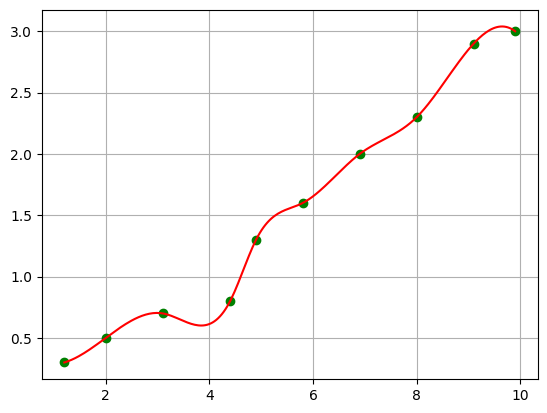

In [45]:
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.pyplot import figure, show
from scipy import interpolate as ip

x = np.array([1.2, 2.0, 3.1, 4.4, 4.9, 5.8, 6.9, 8.0, 9.1, 9.9])
y = np.array([0.3, 0.5, 0.7, 0.8, 1.3, 1.6, 2.0, 2.3, 2.9, 3.0])
 
f = ip.interp1d(x, y, kind='cubic')

newx = np.linspace(np.min(x),np.max(x),250)  # notice outside the original domain
newy = f(newx)

fig = figure()
frame = fig.add_subplot(1,1,1)
frame.plot(x, y, 'go')
frame.plot(newx, newy, 'r')
frame.grid(True)
show()

# This plot is more smoothed out, no spikes, more suitable for interplation

In [47]:
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.pyplot import figure, show
from scipy import interpolate as ip

x = np.array([1.2, 2.0, 3.1, 4.4, 4.9, 5.8, 6.9, 8.0, 9.1, 9.9])
y = np.array([0.3, 0.5, 0.7, 0.8, 1.3, 1.6, 2.0, 2.3, 2.9, 3.0])

class Interpolation():
    def __init__(self,x,y):
        self.x =x
        self.y =y
    def linear(self):
        f = ip.interp1d(self.x, self.y, kind='linear')
        return f
    def polynomial(self,X):
        A = np.zeros((len(self.x),len(self.y))) # x and y need to have the same length

        for j in range(len(self.x)):
            for i in range(len(self.x)):
                A[j,i] = self.x[j]**i #filling the matrix with values

        y = self.y.reshape(len(self.y),1) #to make it a column vector

        a = la.solve(A,y)

        print(a) # These are the coefficients of the polynomial

        #z = np.linspace(np.min(self.x),np.max(self.x),100) # to create a more smooth polynomials curve, this is the domain

        p = 0
        for i in range(len(a)): # creating the polynomial
            p+=a[i]*X**i
        return p
    
    def spline(self):
        f = ip.interp1d(self.x, self.y, kind='cubic')
        return f
    def interpolate(self,X,ftype):
        if ftype == 'linear':
            f = self.linear()
            Y = f(X)
        if ftype == 'polynomial':
            Y = self.polynomial(X)
        if ftype == 'spline':
            f = self.spline()
            Y = f(X)
        return Y

X = np.linspace(np.min(x),np.max(x),250)
ftype = 'spline'

print(Interpolation(x,y).interpolate(X,ftype))


[0.3        0.30457615 0.30971516 0.31539077 0.32157668 0.32824664
 0.33537437 0.3429336  0.35089805 0.35924146 0.36793754 0.37696003
 0.38628265 0.39587914 0.40572321 0.41578859 0.42604902 0.43647822
 0.44704992 0.45773784 0.46851571 0.47935726 0.49023622 0.50112631
 0.51200126 0.52283479 0.53360065 0.54427254 0.5548242  0.56522936
 0.57546175 0.58549508 0.59530309 0.60485951 0.61413806 0.62311247
 0.63175647 0.64004378 0.64794814 0.65544326 0.66250288 0.66910072
 0.67521051 0.68080598 0.68586085 0.69034886 0.69424373 0.69751918
 0.70014895 0.70210676 0.70336633 0.7039014  0.7036857  0.70269294
 0.70089687 0.69827584 0.69487234 0.6907756  0.68607589 0.68086348
 0.67522866 0.66926171 0.6630529  0.6566925  0.65027081 0.64387809
 0.63760463 0.6315407  0.62577659 0.62040256 0.6155089  0.61118588
 0.60752379 0.6046129  0.60254349 0.60140583 0.60129021 0.60228691
 0.6044862  0.60797836 0.61285366 0.6192024  0.62711484 0.63668126
 0.64799194 0.66113716 0.6762072  0.69329233 0.71248284 0.7338

Question 7.7 : Bilinear interpolation

In [49]:
def bilinearIP(I, col, row): # Make it X, Y compatible
    '''I is a two dimensional array and iF,jF is the position at
       which we want to interpolate. 'iF' must be bigger or equal to 0 and
       smaller than the highest index of I in i. The same applies for jF'''
    rowlen, collen= I.shape
    i = int(row)
    j = int(col)
    if row - i == 0 and col - j == 0:  # Falls exactly on a gridpoint
        return I[i,j]

    inbounds = (0 <= j <= collen-1) and (0 <= i <= rowlen-1)
    if not inbounds:
        Iintp = None
    else:
        mu =  row - i
        Lambda = col - j
        # If we are at the last pixel at the right or bottom, then there
        # is not a neighbour, so we take the pixel itself as the neighbour
        I0 = I[i,j]
        I1 = I[i,min(j+1,collen-1)]
        I2 = I[min(i+1,rowlen-1),j]
        I3 = I[min(i+1,rowlen-1),min(j+1,collen-1)]
        Iintp = (1-Lambda)*(1-mu)*I0 + Lambda*(1-mu)*I1 + mu*(1-Lambda)*I2 + Lambda*mu*I3
    return(Iintp)

In [52]:
I = np.array([[2.0,4.1], [2.5,3.8]])
print(I)

x=0.2
y=0.7

# Row position is y value
# Column position is x value

Iintp = bilinearIP(I, x, y)
if Iintp:
    print(f"The interpolated intensity at (i,j)={y},{x} => (x, y)={x},{y} is {Iintp:.6f}")
else:
    print("One of the indices was outside the limits")


[[2.  4.1]
 [2.5 3.8]]
The interpolated intensity at (i,j)=0.7,0.2 => (x, y)=0.2,0.7 is 2.658000


Question 7.10 : Fitting the Lemaitre-Hubble relation

Intercept beta0=47.02849670178006, slope beta1=67.53016862801742


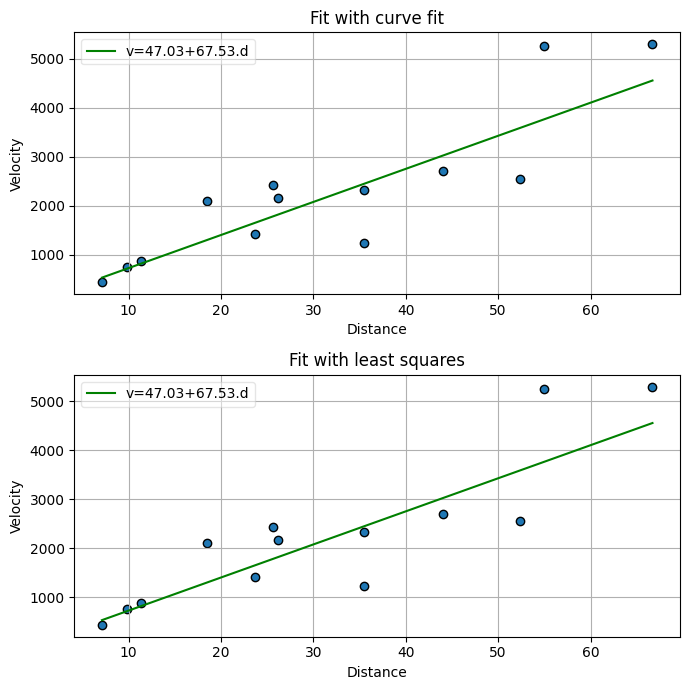

In [68]:
import numpy as np
data = [
         18.49,      2094.75,    0.3,           200,
         35.48,     2320.87,    2.2,           220,
         35.48,     1224.9,     3.0,           180,
         11.34,     872.13,     1.2,           180,
         7.12,      432.2,      0.4,           170,
         9.82,      751,        0.3,           175,
         23.66,     1410,       2.3,           170,
         44,        2700,       4.0,           210,
         66.7,      5292,       5.3,           220,
         52.4,      2550,       5.2,           200,
         55,        5253,       6.1,           250,
         25.6,      2419,       3.2,           210,
         26.19,     2158,       2.8,           210]


data = np.asarray(data)
d = data[0::4]; v = data[1::4]
sigd= data[2::4]; sigv= data[3::4]

from matplotlib.pyplot import subplots, show
from scipy.optimize import curve_fit,leastsq

def model(x, beta0, beta1):
    """The model with parameters a and b. Note that for the Hubble relation we fix a to 0.0"""
    return beta0 + beta1*x

# Do the fitting
beta, pcov = curve_fit(model, d, v,sigma =(sigv))
print(f"Intercept beta0={beta[0]}, slope beta1={beta[1]}")

# Calculate end points for the best straight line
D = np.array([d.min(),d.max()])
V = model(D, beta[0], beta[1])

fig = figure(figsize = (7,7))
frame = fig.add_subplot(2,1,1)
frame.scatter(d, v, marker='o', ec='k')
frame.set_xlabel('Distance')
frame.set_ylabel('Velocity')
frame.set_title('Fit with curve fit')
label = f"v={beta[0]:.2f}+{beta[1]:.2f}.d"
frame.plot(D, V, label=label, color='green')
frame.legend(fancybox=True, framealpha=0.5)
frame.grid(True)

# The model, usually a function of x
def model(beta, x):
    beta0, beta1 = beta
    return beta0 + beta1*x

# A residuals function
def residuals(beta, x, y, sigy):
    return (y - model(beta,x))/sigy

beta_start = [0, 70.0]          # Initial estimates for beta0 and beta1
data = (d, v, sigv)             # You need to pack your data in a tuple
result = leastsq(residuals, beta_start, args=data, full_output=1)
(beta, pcov, infodict, errmsg, ier) = result       # Unpack tuple with results

frame = fig.add_subplot(2,1,2)
frame.scatter(d, v, marker='o', ec='k')
frame.set_xlabel('Distance')
frame.set_ylabel('Velocity')
frame.set_title('Fit with least squares')
label = f"v={beta[0]:.2f}+{beta[1]:.2f}.d"
frame.plot(D, V, label=label, color='green')
frame.legend(fancybox=True, framealpha=0.5)
frame.grid(True)
fig.tight_layout()
show()

Question 7.14 : Introduction to GitHub Branches